<a href="https://colab.research.google.com/github/Gebrhans/maize-disease-detection/blob/main/AIGRAMMERANALYZERANERROR_CORECTOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


==================== Rule-Based ====================
                   precision    recall  f1-score   support

  agreement_fault       1.00      0.16      0.27        88
          correct       0.61      1.00      0.76       117
gender_bias_fault       1.00      1.00      1.00        98
      tense_fault       1.00      1.00      1.00        97

         accuracy                           0.81       400
        macro avg       0.90      0.79      0.76       400
     weighted avg       0.89      0.81      0.77       400



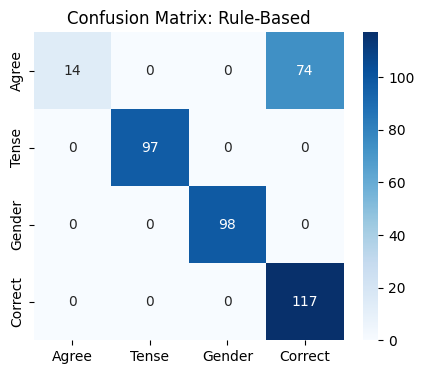


==================== Machine Learning ====================
                   precision    recall  f1-score   support

  agreement_fault       0.85      0.86      0.86        88
          correct       0.90      0.89      0.89       117
gender_bias_fault       1.00      1.00      1.00        98
      tense_fault       1.00      1.00      1.00        97

         accuracy                           0.94       400
        macro avg       0.94      0.94      0.94       400
     weighted avg       0.94      0.94      0.94       400



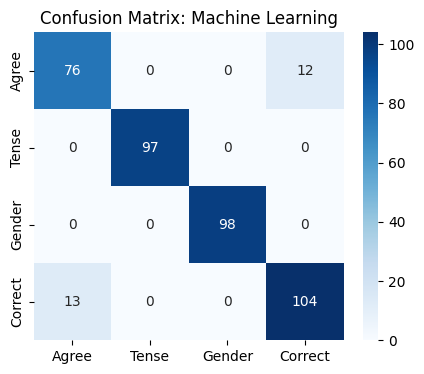


==================== Hybrid Model ====================
                   precision    recall  f1-score   support

  agreement_fault       0.85      0.86      0.86        88
          correct       0.90      0.89      0.89       117
gender_bias_fault       1.00      1.00      1.00        98
      tense_fault       1.00      1.00      1.00        97

         accuracy                           0.94       400
        macro avg       0.94      0.94      0.94       400
     weighted avg       0.94      0.94      0.94       400



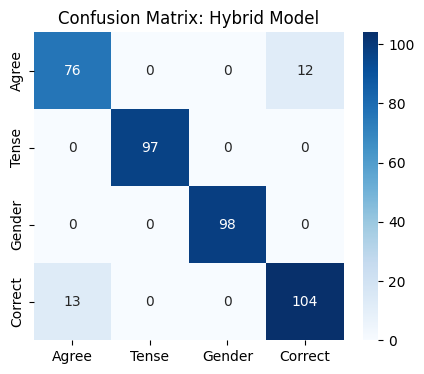

In [ ]:
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline

# --- 1. DATASET GENERATION (Exactly 500 per category = 2000 total) ---
subjects_masc = ["ንሱ", "ተምሃራይ", "ሓኪም", "ኣቦ", "ወዲ", "ኢንጅነር"]
subjects_fem = ["ንሳ", "ተምሃሪት", "ሓኪም", "ኣደ", "ጓል", "ኢንጅነር"]
verbs_masc = ["ይፈልጥ", "ይጽሕፍ", "ሰሪሑ", "ይረድእ"]
verbs_fem = ["ትፈልጥ", "ትጽሕፍ", "ሰሪሓ", "ትረድእ"]
objects = ["ነቲ ፕሮጀክት", "ደብዳቤ", "ጽቡቕ ጌሩ", "እዋናዊ ጸብጻብ"]
past_markers = ["ትማሊ", "ቅድሚ ክልተ መዓልቲ", "ዓሚ", "ሕሉፍ ሰሙን"]
biased = ["ሰብኣይ መሪሕነት", "ሊቀመንበር", "ፖሊስ ሰብኣይ"]

dataset = []
# Create 500 of each
for _ in range(500):
    dataset.append((f"{random.choice(subjects_masc)} {random.choice(objects)} {random.choice(verbs_fem)}::", "agreement_fault"))
    dataset.append((f"{random.choice(past_markers)} {random.choice(subjects_masc)} {random.choice(objects)} {random.choice(verbs_masc)}::", "tense_fault"))
    dataset.append((f"እቲ {random.choice(biased)} ነቲ ስራሕ ኣሳሊጥዎ::", "gender_bias_fault"))
    dataset.append((f"{random.choice(subjects_fem)} {random.choice(objects)} {random.choice(verbs_fem)}::", "correct"))

random.shuffle(dataset)
sentences, labels = zip(*dataset)

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(sentences, labels, test_size=0.2, random_state=42)

# --- 2. MODELS ---
# Machine Learning Model
ml_model = make_pipeline(TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5)), MultinomialNB())
ml_model.fit(X_train, y_train)

# Rule-Based Logic
def rule_based_predict(text):
    if "ንሱ" in text and any(v in text for v in verbs_fem): return "agreement_fault"
    if any(m in text for m in past_markers) and not "ነይሩ" in text: return "tense_fault"
    if any(b in text for b in biased): return "gender_bias_fault"
    return "correct"

y_pred_ml = ml_model.predict(X_test)
y_pred_rule = [rule_based_predict(s) for s in X_test]
# Hybrid: Rule-based logic takes precedence, ML handles the rest
y_pred_hybrid = [y_pred_rule[i] if y_pred_rule[i] != "correct" else y_pred_ml[i] for i in range(len(X_test))]

# --- 3. EVALUATION ---
models = [("Rule-Based", y_pred_rule), ("Machine Learning", y_pred_ml), ("Hybrid Model", y_pred_hybrid)]

for name, y_pred in models:
    print(f"\n{'='*20} {name} {'='*20}")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred, labels=['agreement_fault', 'tense_fault', 'gender_bias_fault', 'correct'])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Agree', 'Tense', 'Gender', 'Correct'],
                yticklabels=['Agree', 'Tense', 'Gender', 'Correct'])
    plt.title(f'Confusion Matrix: {name}')
    plt.show()


========== Comparison: Logistic Regression ==========
                   precision    recall  f1-score   support

  agreement_fault       0.88      0.86      0.87       102
          correct       0.86      0.88      0.87        96
gender_bias_fault       1.00      1.00      1.00        98
      tense_fault       1.00      1.00      1.00       104

         accuracy                           0.94       400
        macro avg       0.93      0.93      0.93       400
     weighted avg       0.94      0.94      0.94       400



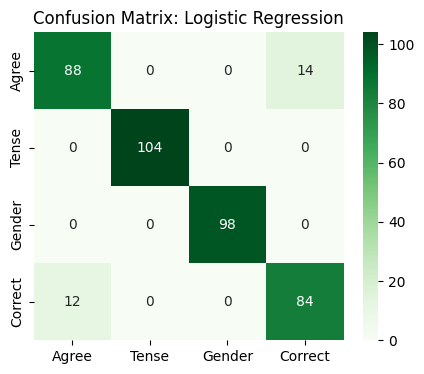


========== Comparison: Random Forest ==========
                   precision    recall  f1-score   support

  agreement_fault       0.89      0.81      0.85       102
          correct       0.82      0.90      0.86        96
gender_bias_fault       1.00      1.00      1.00        98
      tense_fault       1.00      1.00      1.00       104

         accuracy                           0.93       400
        macro avg       0.93      0.93      0.93       400
     weighted avg       0.93      0.93      0.93       400



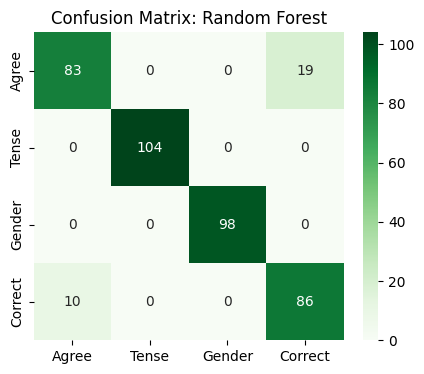


========== Comparison: Linear SVM ==========
                   precision    recall  f1-score   support

  agreement_fault       0.89      0.85      0.87       102
          correct       0.85      0.89      0.87        96
gender_bias_fault       1.00      1.00      1.00        98
      tense_fault       1.00      1.00      1.00       104

         accuracy                           0.94       400
        macro avg       0.93      0.93      0.93       400
     weighted avg       0.94      0.94      0.94       400



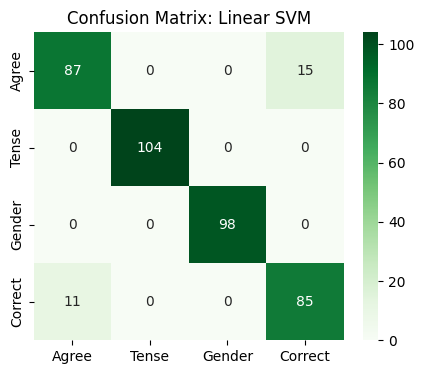

In [ ]:
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline

# --- 1. DATASET GENERATION ---
subjects_masc = ["ንሱ", "ተምሃራይ", "ሓኪም", "ኣቦ", "ወዲ", "ኢንጅነር"]
subjects_fem = ["ንሳ", "ተምሃሪት", "ሓኪም", "ኣደ", "ጓል", "ኢንጅነር"]
verbs_masc = ["ይፈልጥ", "ይጽሕፍ", "ሰሪሑ", "ይረድእ"]
verbs_fem = ["ትፈልጥ", "ትጽሕፍ", "ሰሪሓ", "ትረድእ"]
objects = ["ነቲ ፕሮጀክት", "ደብዳቤ", "ጽቡቕ ጌሩ", "እዋናዊ ጸብጻብ"]
past_markers = ["ትማሊ", "ቅድሚ ክልተ መዓልቲ", "ዓሚ", "ሕሉፍ ሰሙን"]
biased = ["ሰብኣይ መሪሕነት", "ሊቀመንበር", "ፖሊስ ሰብኣይ"]

dataset = []
for _ in range(500):
    dataset.append((f"{random.choice(subjects_masc)} {random.choice(objects)} {random.choice(verbs_fem)}::", "agreement_fault"))
    dataset.append((f"{random.choice(past_markers)} {random.choice(subjects_masc)} {random.choice(objects)} {random.choice(verbs_masc)}::", "tense_fault"))
    dataset.append((f"እቲ {random.choice(biased)} ነቲ ስራሕ ኣሳሊጥዎ::", "gender_bias_fault"))
    dataset.append((f"{random.choice(subjects_fem)} {random.choice(objects)} {random.choice(verbs_fem)}::", "correct"))

random.shuffle(dataset)
sentences, labels = zip(*dataset)
X_train, X_test, y_train, y_test = train_test_split(sentences, labels, test_size=0.2, random_state=42)

# --- 2. THREE MODERN ALGORITHMS ---
models_to_compare = [
    ("Logistic Regression", make_pipeline(TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5)), LogisticRegression(max_iter=1000))),
    ("Random Forest", make_pipeline(TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5)), RandomForestClassifier(n_estimators=100))),
    ("Linear SVM", make_pipeline(TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5)), LinearSVC(dual="auto")))
]

# --- 3. COMPARISON & EVALUATION ---
for name, model in models_to_compare:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{'='*10} Comparison: {name} {'='*10}")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=['agreement_fault', 'tense_fault', 'gender_bias_fault', 'correct'])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Agree', 'Tense', 'Gender', 'Correct'],
                yticklabels=['Agree', 'Tense', 'Gender', 'Correct'])
    plt.title(f'Confusion Matrix: {name}')
    plt.show()


==================== Naive Bayes Performance ====================
                   precision    recall  f1-score   support

  agreement_fault       0.83      0.82      0.83        97
          correct       0.85      0.85      0.85       110
gender_bias_fault       1.00      1.00      1.00       103
      tense_fault       1.00      1.00      1.00        90

         accuracy                           0.92       400
        macro avg       0.92      0.92      0.92       400
     weighted avg       0.92      0.92      0.92       400



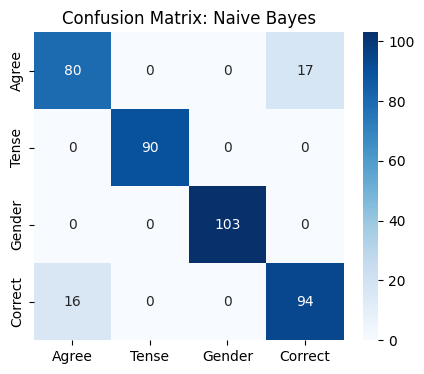


==================== Logistic Regression Performance ====================
                   precision    recall  f1-score   support

  agreement_fault       0.81      0.81      0.81        97
          correct       0.84      0.84      0.84       110
gender_bias_fault       1.00      1.00      1.00       103
      tense_fault       1.00      1.00      1.00        90

         accuracy                           0.91       400
        macro avg       0.91      0.91      0.91       400
     weighted avg       0.91      0.91      0.91       400



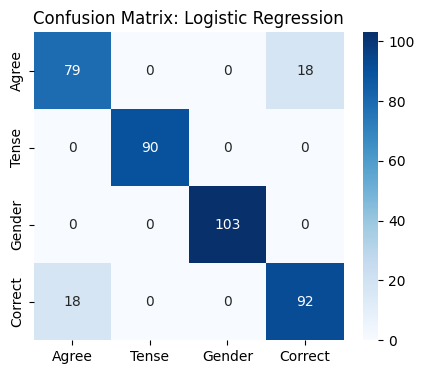


==================== Random Forest Performance ====================
                   precision    recall  f1-score   support

  agreement_fault       0.83      0.85      0.84        97
          correct       0.86      0.85      0.85       110
gender_bias_fault       1.00      1.00      1.00       103
      tense_fault       1.00      1.00      1.00        90

         accuracy                           0.92       400
        macro avg       0.92      0.92      0.92       400
     weighted avg       0.92      0.92      0.92       400



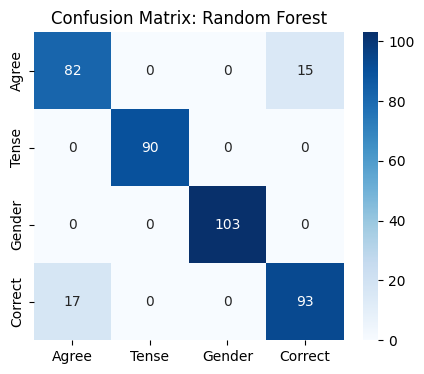


==================== Linear SVM Performance ====================
                   precision    recall  f1-score   support

  agreement_fault       0.84      0.73      0.78        97
          correct       0.79      0.87      0.83       110
gender_bias_fault       1.00      1.00      1.00       103
      tense_fault       1.00      1.00      1.00        90

         accuracy                           0.90       400
        macro avg       0.91      0.90      0.90       400
     weighted avg       0.90      0.90      0.90       400



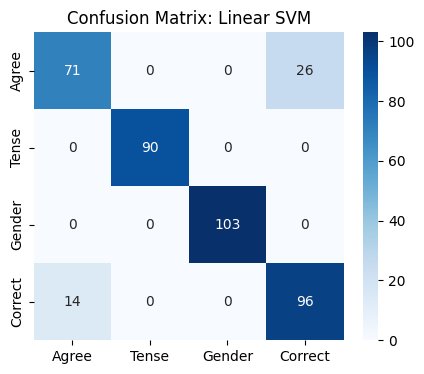

In [ ]:
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline

# --- 1. DATASET GENERATION (2,000 Total) ---
# [Data generation logic remains the same as previously defined]
subjects_masc = ["ንሱ", "ተምሃራይ", "ሓኪም", "ኣቦ", "ወዲ", "ኢንጅነር"]
subjects_fem = ["ንሳ", "ተምሃሪት", "ሓኪም", "ኣደ", "ጓል", "ኢንጅነር"]
verbs_masc = ["ይፈልጥ", "ይጽሕፍ", "ሰሪሑ", "ይረድእ"]
verbs_fem = ["ትፈልጥ", "ትጽሕፍ", "ሰሪሓ", "ትረድእ"]
objects = ["ነቲ ፕሮጀክት", "ደብዳቤ", "ጽቡቕ ጌሩ", "እዋናዊ ጸብጻብ"]
past_markers = ["ትማሊ", "ቅድሚ ክልተ መዓልቲ", "ዓሚ", "ሕሉፍ ሰሙን"]
biased = ["ሰብኣይ መሪሕነት", "ሊቀመንበር", "ፖሊስ ሰብኣይ"]

dataset = []
for _ in range(500):
    dataset.append((f"{random.choice(subjects_masc)} {random.choice(objects)} {random.choice(verbs_fem)}::", "agreement_fault"))
    dataset.append((f"{random.choice(past_markers)} {random.choice(subjects_masc)} {random.choice(objects)} {random.choice(verbs_masc)}::", "tense_fault"))
    dataset.append((f"እቲ {random.choice(biased)} ነቲ ስራሕ ኣሳሊጥዎ::", "gender_bias_fault"))
    dataset.append((f"{random.choice(subjects_fem)} {random.choice(objects)} {random.choice(verbs_fem)}::", "correct"))

random.shuffle(dataset)
sentences, labels = zip(*dataset)
X_train, X_test, y_train, y_test = train_test_split(sentences, labels, test_size=0.2, random_state=42)

# --- 2. MODEL COMPARISON SUITE ---
# Including Naive Bayes alongside modern alternatives
models_to_compare = [
    ("Naive Bayes", make_pipeline(TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5)), MultinomialNB())),
    ("Logistic Regression", make_pipeline(TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5)), LogisticRegression(max_iter=1000))),
    ("Random Forest", make_pipeline(TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5)), RandomForestClassifier(n_estimators=100))),
    ("Linear SVM", make_pipeline(TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5)), LinearSVC(dual="auto")))
]

# --- 3. EVALUATION & VISUALIZATION ---
for name, model in models_to_compare:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{'='*20} {name} Performance {'='*20}")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred, labels=['agreement_fault', 'tense_fault', 'gender_bias_fault', 'correct'])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Agree', 'Tense', 'Gender', 'Correct'],
                yticklabels=['Agree', 'Tense', 'Gender', 'Correct'])
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

# New Section

# New Section